# Illustratability distribution by domain

This notebook describes all **900 eligible candidates**, not a reconstruction job
or the selected 90-title dataset. The archived rating job is the default input.
Restart the kernel and **Run All**; no model service is needed.

Each title contributes the equal mean of Q25, G3, Q38 and G4. All four integer
ratings (0–100) must be valid. Incomplete means are counted, never imputed.
These are model judgments, not human labels or probabilities of reconstruction.

The plot checks concentration, asymmetry and tails within each domain. A skewed
distribution is not itself a defect: no normality requirement, automatic cutoff
or dataset filtering is applied. The random main sample remains unchanged.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.ticker import MaxNLocator

from semantic_roundtrip.analysis import load_job
from semantic_roundtrip.analysis.plotting import save_figure
from semantic_roundtrip.analysis.reporting import (
    DOMAINS,
    QG,
    candidate_roster,
    candidate_tables,
    export_tables,
    histogram_counts,
    write_manifest,
)

# Run from the repository root or its notebooks/ directory.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sns.set_theme(
    style="whitegrid",
    context="notebook",
    rc={"pdf.fonttype": 42, "ps.fonttype": 42, "axes.unicode_minus": False},
)

In [2]:
# Use an absolute job-directory path here, or keep the shipped reproducible input.
RATING_JOB = (
    Path(
        os.getenv(
            "RATING_JOB",
            ROOT
            / "artifacts/candidate_illustratability/20260902T162529Z_candidate-illustratability_a1cfe5f2",
        )
    )
    .expanduser()
    .resolve()
)
OUTPUT_DIR = (
    Path(
        os.getenv(
            "OUTPUT_DIR", ROOT / "notebooks/results/illustratability_distribution"
        )
    )
    .expanduser()
    .resolve()
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
job = load_job(RATING_JOB, entries=[f"rating_{model}" for model in QG])
roster = candidate_roster(RATING_JOB)
scores, counts, model_counts = candidate_tables(roster, job.ratings)
bins = np.arange(0, 101, 5)  # 20 identical bins; the last bin includes 100.

## Equal four-model means

One panel per domain, identical axes and five-point bins. Every complete title
counts once. The panel heading reports the full roster and missing means.

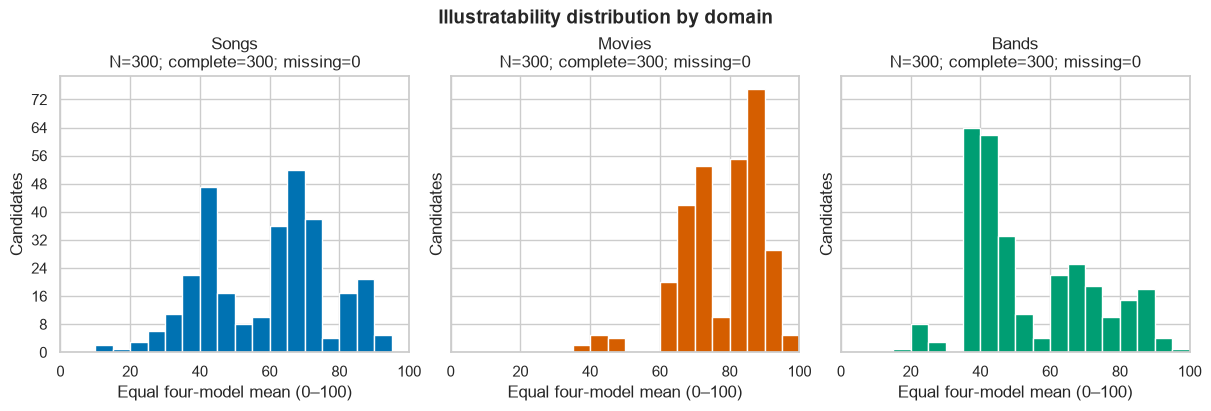

In [4]:
fig, axes = plt.subplots(
    1, 3, figsize=(12, 4), sharex=True, sharey=True, layout="constrained"
)
for domain, ax in zip(DOMAINS, axes):
    values = scores.loc[scores.domain.eq(domain), "mean_score"].dropna()
    n = counts.loc[domain]
    ax.hist(values, bins=bins, color=DOMAINS[domain][0], edgecolor="white")
    ax.set(
        title=f"{domain.title()}\nN={int(n.candidates)}; complete={int(n.complete_four_model_means)}; missing={int(n.missing_means)}",
        xlabel="Equal four-model mean (0–100)",
        ylabel="Candidates",
        xlim=(0, 100),
    )
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
save_figure(
    fig,
    OUTPUT_DIR / "candidate_pool_distribution",
    "Illustratability distribution by domain",
)

## Reproducibility exports

The CSVs contain every individual score and mean, missing/invalid counts and the
exact histogram bins. `manifest.json` records input hashes, source code and
software versions. It documents provenance; it does not change the dataset.

In [5]:
export_tables(
    {
        "candidate_pool_scores": scores,
        "candidate_pool_counts": counts.reset_index(),
        "candidate_pool_model_counts": model_counts.reset_index(),
        "candidate_pool_histogram": histogram_counts(scores, bins),
    },
    OUTPUT_DIR,
)
write_manifest(
    ROOT / "notebooks/illustratability_distribution.ipynb",
    {"Candidate pool": RATING_JOB},
    OUTPUT_DIR,
    analysis={
        "purpose": "candidate_distribution",
        "population": "all eligible candidates",
        "aggregation": "equal Q25/G3/Q38/G4 mean; four valid integer ratings required; no imputation",
        "histogram_bins": bins.tolist(),
        "bin_convention": "[left, right), last bin includes 100",
    },
)